# Heart Disease Detection using Classification Algorithms
Upload your heart disease CSV (with target column named `output`; if yours differs, replace `output` accordingly).

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

plt.rcParams["figure.figsize"]=(8,5)


In [ ]:
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)
df.head()

Saving heart_disease_dataset.csv to heart_disease_dataset.csv


,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
0,58,1,1,134,246,0,0,155,0,0.4,1,1,2,1
1,52,0,2,112,245,0,0,143,1,0.1,0,0,3,1
2,59,0,2,126,196,0,0,162,1,1.1,1,0,1,1
3,67,1,1,165,201,0,0,180,0,0.4,2,0,2,0
4,51,1,0,146,174,1,1,133,1,0.9,1,1,2,1


In [ ]:
print(df.columns)
print(df.shape)
df.info()
df.describe()

Index(['age', 'sex', 'chest_pain_type', 'resting_blood_pressure',
       'cholesterol', 'fasting_blood_sugar', 'resting_ecg', 'max_heart_rate',
       'exercise_induced_angina', 'st_depression', 'st_slope',
       'num_major_vessels', 'thalassemia', 'heart_disease'],
      dtype='object')
(400, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      400 non-null    int64  
 1   sex                      400 non-null    int64  
 2   chest_pain_type          400 non-null    int64  
 3   resting_blood_pressure   400 non-null    int64  
 4   cholesterol              400 non-null    int64  
 5   fasting_blood_sugar      400 non-null    int64  
 6   resting_ecg              400 non-null    int64  
 7   max_heart_rate           400 non-null    int64  
 8   exercise_induced_angina  400 non-null    int64  
 

,age,sex,chest_pain_type,resting_blood_pressure,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_induced_angina,st_depression,st_slope,num_major_vessels,thalassemia,heart_disease
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,53.667500,0.662500,1.712500,123.630000,216.627500,0.140000,0.530000,146.717500,0.29250,0.753250,1.177500,0.677500,1.925000,0.555000
std,8.508403,0.473449,1.035628,16.567114,41.379941,0.347422,0.533678,21.104293,0.45548,0.772841,0.645784,0.889084,0.689611,0.497588
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,91.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,1.000000,112.000000,188.000000,0.000000,0.000000,132.000000,0.00000,0.200000,1.000000,0.000000,2.000000,0.000000
50%,54.000000,1.000000,2.000000,124.000000,216.000000,0.000000,1.000000,146.000000,0.00000,0.600000,1.000000,0.000000,2.000000,1.000000
75%,59.000000,1.000000,3.000000,135.000000,246.000000,0.000000,1.000000,161.000000,1.00000,0.900000,2.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,174.000000,336.000000,1.000000,2.000000,202.000000,1.00000,4.900000,2.000000,3.000000,3.000000,1.000000


In [ ]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

age                        0
sex                        0
chest_pain_type            0
resting_blood_pressure     0
cholesterol                0
fasting_blood_sugar        0
resting_ecg                0
max_heart_rate             0
exercise_induced_angina    0
st_depression              0
st_slope                   0
num_major_vessels          0
thalassemia                0
heart_disease              0
dtype: int64
Duplicates: 0


## Exploratory Data Analysis

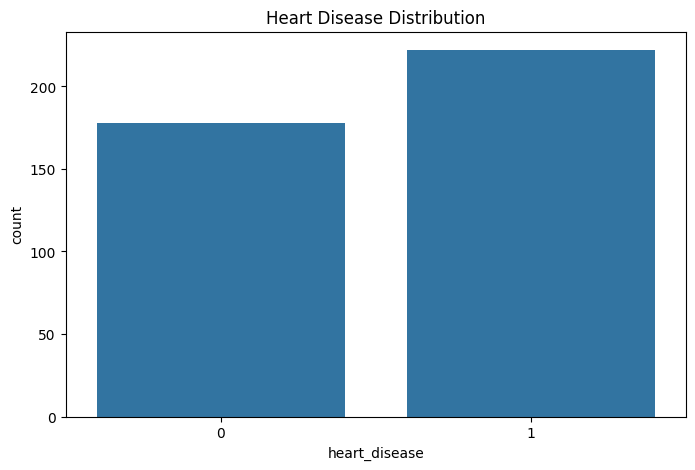

In [ ]:
sns.countplot(x='heart_disease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

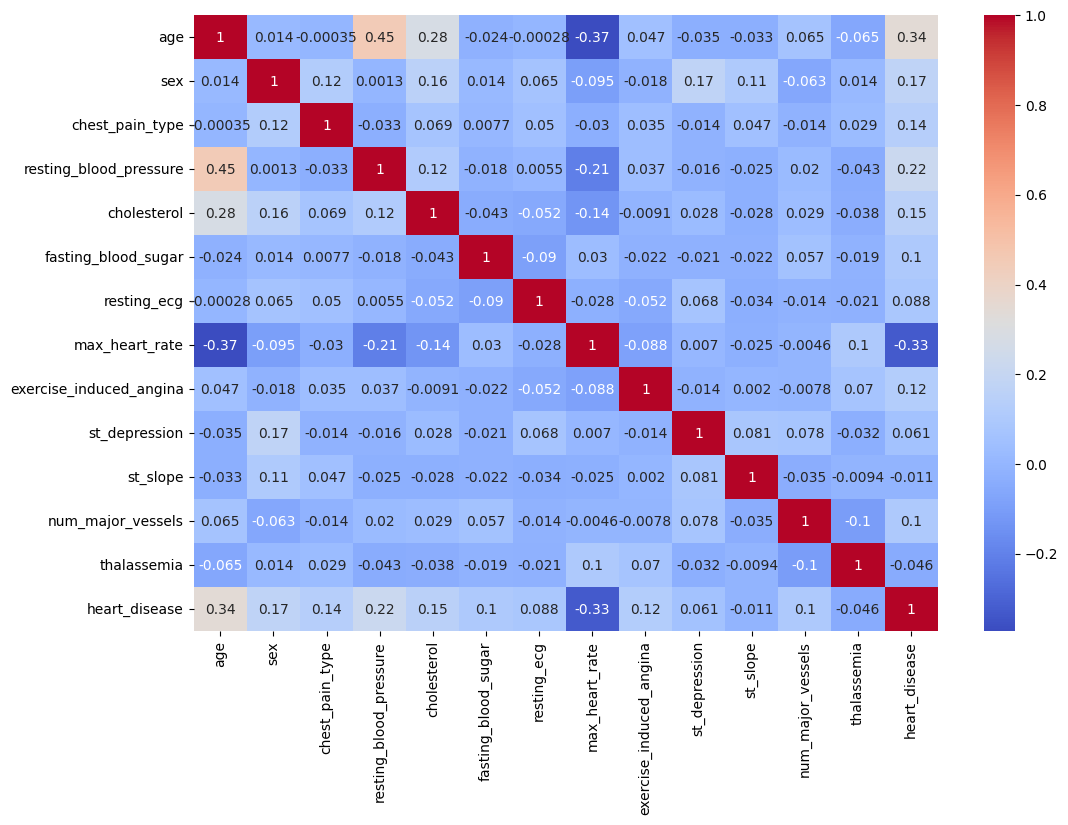

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

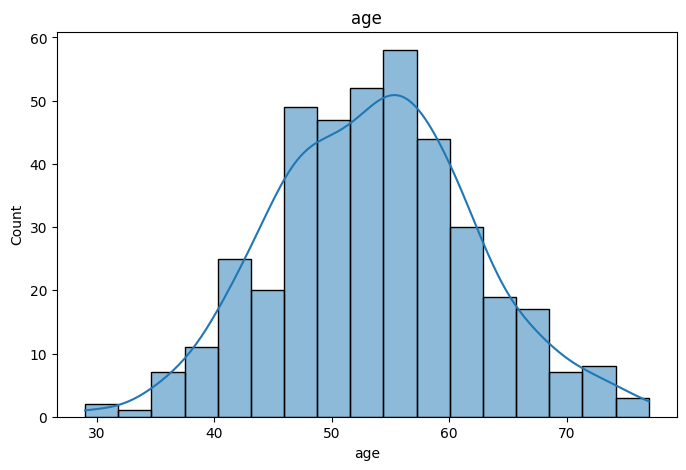

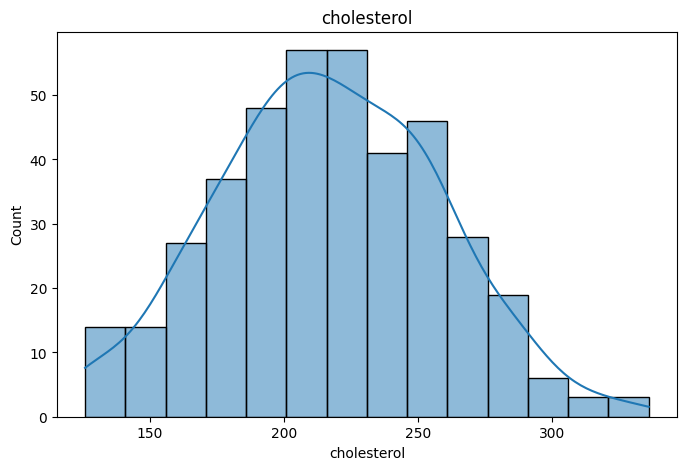

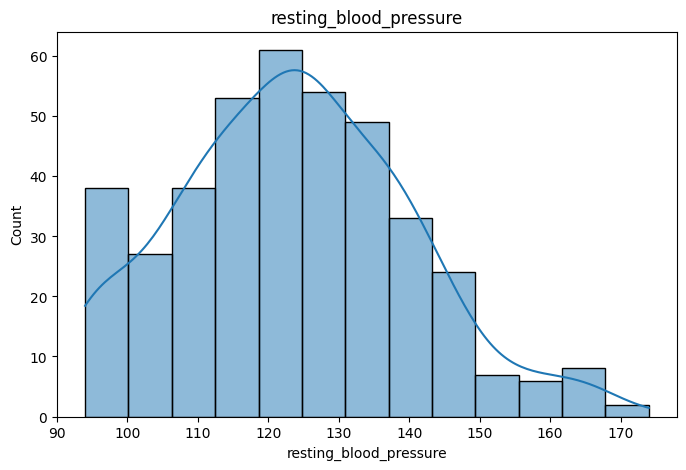

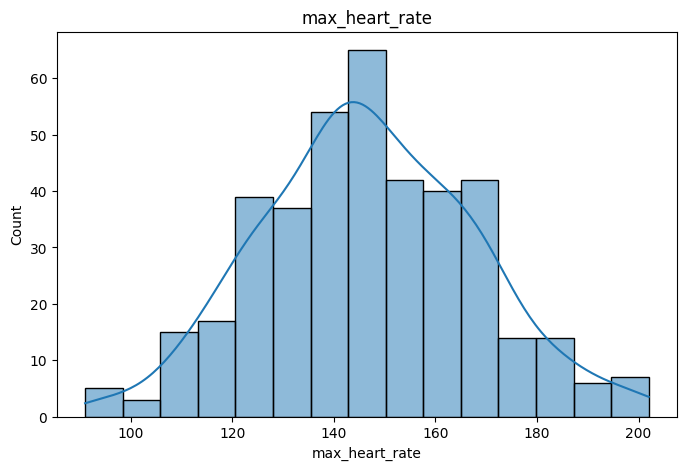

In [ ]:
for col in ['age','cholesterol','resting_blood_pressure','max_heart_rate']:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [ ]:
X=df.drop('heart_disease',axis=1)
y=df['heart_disease']

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [ ]:
models={
    'Logistic Regression':LogisticRegression(max_iter=1000),
    'KNN':KNeighborsClassifier(),
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest':RandomForestClassifier(random_state=42),
    'SVM':SVC(probability=True)
}

results={}

for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    acc=accuracy_score(y_test,pred)
    results[name]=acc
    print("="*50)
    print(name)
    print("Accuracy:",acc)
    print(confusion_matrix(y_test,pred))
    print(classification_report(y_test,pred))


Logistic Regression
Accuracy: 0.675
[[22 14]
 [12 32]]
              precision    recall  f1-score   support

           0       0.65      0.61      0.63        36
           1       0.70      0.73      0.71        44

    accuracy                           0.68        80
   macro avg       0.67      0.67      0.67        80
weighted avg       0.67      0.68      0.67        80

KNN
Accuracy: 0.625
[[24 12]
 [18 26]]
              precision    recall  f1-score   support

           0       0.57      0.67      0.62        36
           1       0.68      0.59      0.63        44

    accuracy                           0.62        80
   macro avg       0.63      0.63      0.62        80
weighted avg       0.63      0.62      0.63        80

Decision Tree
Accuracy: 0.575
[[16 20]
 [14 30]]
              precision    recall  f1-score   support

           0       0.53      0.44      0.48        36
           1       0.60      0.68      0.64        44

    accuracy                           

In [ ]:
best_name=max(results,key=results.get)
best_model=models[best_name]
print("Best Model:",best_name)
print(results)

Best Model: Logistic Regression
{'Logistic Regression': 0.675, 'KNN': 0.625, 'Decision Tree': 0.575, 'Random Forest': 0.675, 'SVM': 0.65}


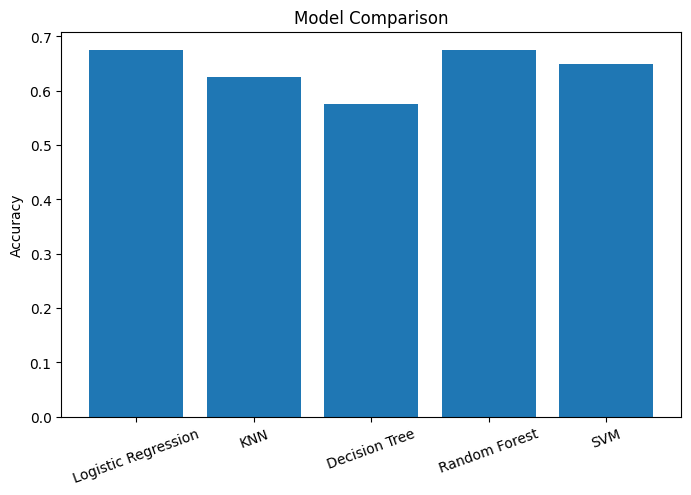

In [ ]:
plt.bar(results.keys(),results.values())
plt.xticks(rotation=20)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

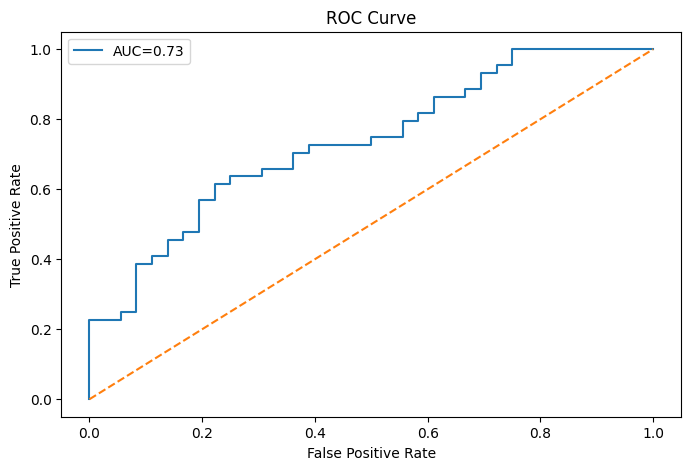

In [ ]:
probs=best_model.predict_proba(X_test)[:,1]
fpr,tpr,_=roc_curve(y_test,probs)
roc_auc=auc(fpr,tpr)

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
if hasattr(best_model,'feature_importances_'):
    imp=pd.DataFrame({
        'Feature':X.columns,
        'Importance':best_model.feature_importances_
    }).sort_values('Importance',ascending=False)

    sns.barplot(data=imp,x='Importance',y='Feature')
    plt.title("Feature Importance")
    plt.show()
else:
    print("Feature importance not available for",best_name)


Feature importance not available for Logistic Regression


## User Prediction

Enter Patient Details
age: 23
sex (0=Female, 1=Male): 1
chest_pain_type (0=Typical Angina, 1=Atypical Angina, 2=Non-Anginal Pain, 3=Asymptomatic): 3
resting_blood_pressure: 90
cholesterol: 130
fasting_blood_sugar (Enter 1 if blood sugar >120mg/dl, 0 if <=120mg/dl): 1
resting_ecg (0=Normal, 1=ST-T Wave Abnormality, 2=Left Ventricular Hypertrophy): 0
max_heart_rate: 80
exercise_induced_angina (Yes: 1, No: 0): 0
st_depression: 22
st_slope (0=Upsloping, 1=Flat, 2=Downsloping): 1
num_major_vessels: 32
thalassemia (0=Normal, 1=Fixed Defect, 2=Reversible Defect): 0

========== REPORT ==========
Prediction: Heart Disease Detected
Probability: 100.00%
Risk Level: High


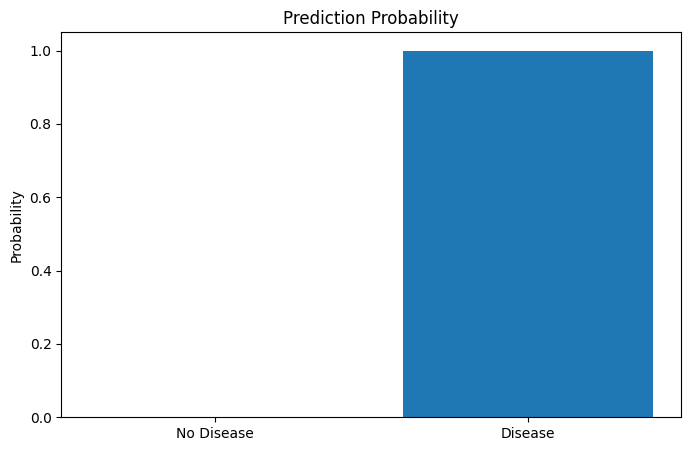

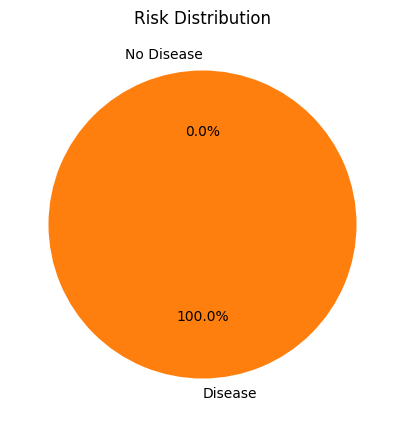

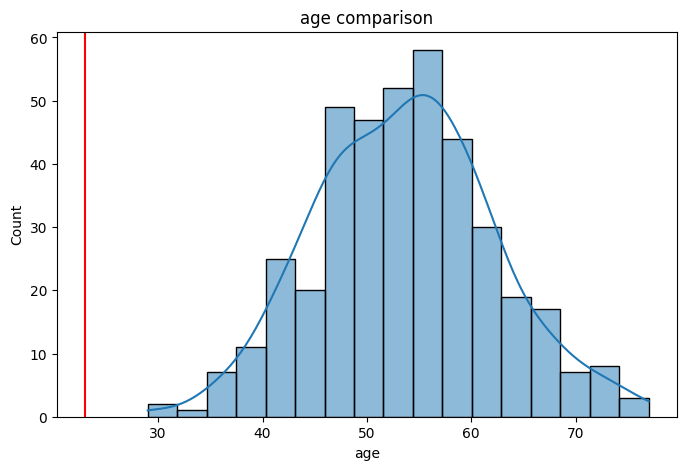

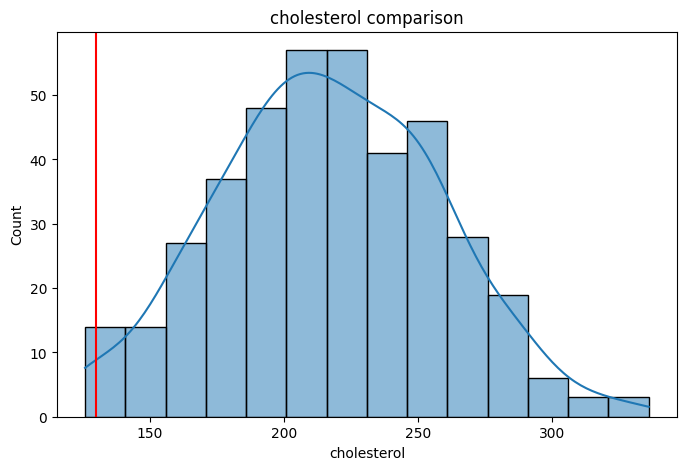

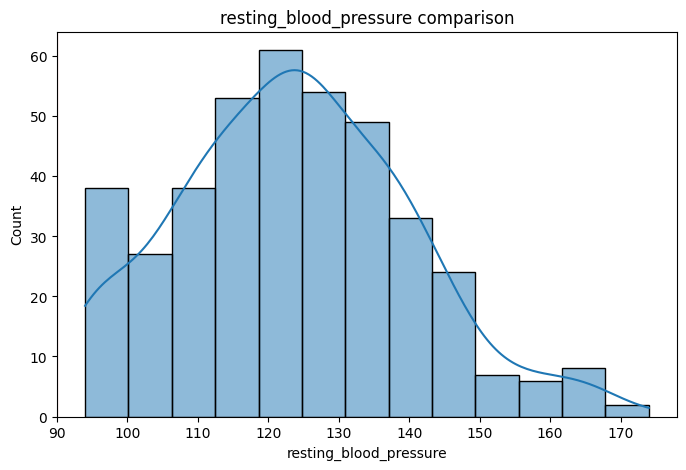

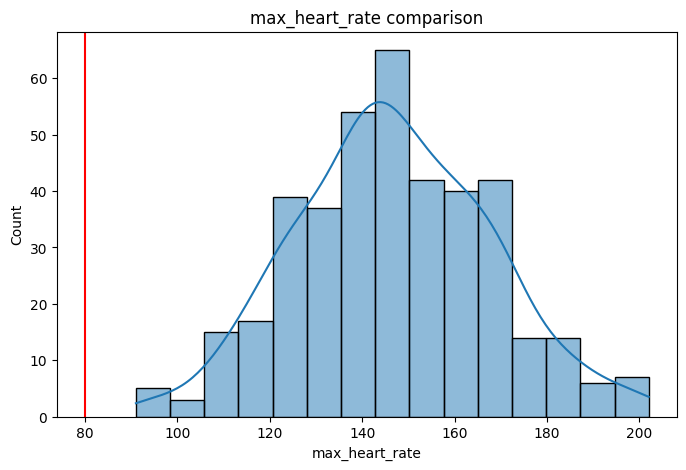


Health Advice:
- Consult a cardiologist.
- Maintain a healthy diet.
- Exercise regularly.
- Monitor blood pressure and cholesterol.


In [ ]:
print("Enter Patient Details")
vals=[]
for col in X.columns:
    if col == 'sex':
        vals.append(float(input(f"{col} (0=Female, 1=Male): ")))
    elif col == 'chest_pain_type':
        vals.append(float(input(f"{col} (0=Typical Angina, 1=Atypical Angina, 2=Non-Anginal Pain, 3=Asymptomatic): ")))
    elif col == 'fasting_blood_sugar':
        vals.append(float(input(f"{col} (Enter 1 if blood sugar >120mg/dl, 0 if <=120mg/dl): ")))
    elif col == 'resting_ecg':
        vals.append(float(input(f"{col} (0=Normal, 1=ST-T Wave Abnormality, 2=Left Ventricular Hypertrophy): ")))
    elif col == 'exercise_induced_angina':
        vals.append(float(input(f"{col} (Yes: 1, No: 0): ")))
    elif col == 'st_slope':
        vals.append(float(input(f"{col} (0=Upsloping, 1=Flat, 2=Downsloping): ")))
    elif col == 'thalassemia':
        vals.append(float(input(f"{col} (0=Normal, 1=Fixed Defect, 2=Reversible Defect): ")))
    else:
        vals.append(float(input(f"{col}: ")))

patient_df = pd.DataFrame([vals], columns=X.columns)
patient_scaled=scaler.transform(patient_df)

prediction=best_model.predict(patient_scaled)[0]
prob=best_model.predict_proba(patient_scaled)[0]

print("\n========== REPORT ==========")
print("Prediction:",
      "Heart Disease Detected" if prediction==1 else "No Heart Disease")
print(f"Probability: {prob[prediction]*100:.2f}%")

risk=prob[1]*100
if risk<30:
    level="Low"
elif risk<70:
    level="Medium"
else:
    level="High"

print("Risk Level:",level)

plt.figure()
plt.bar(['No Disease','Disease'],prob)
plt.ylabel("Probability")
plt.title("Prediction Probability")
plt.show()

plt.figure()
plt.pie(prob,labels=['No Disease','Disease'],autopct='%1.1f%%',startangle=90)
plt.title("Risk Distribution")
plt.show()

for feature in ['age','cholesterol','resting_blood_pressure','max_heart_rate']:
    if feature in X.columns:
        plt.figure()
        sns.histplot(df[feature],kde=True)
        idx=list(X.columns).index(feature)
        plt.axvline(vals[idx],color='red')
        plt.title(feature+' comparison')
        plt.show()

print("\nHealth Advice:")
if prediction==1:
    print("- Consult a cardiologist.")
    print("- Maintain a healthy diet.")
    print("- Exercise regularly.")
    print("- Monitor blood pressure and cholesterol.")
else:
    print("- Continue a healthy lifestyle.")

# Use following demo reports for output

🟢 Demo 1: Healthy Patient (Negative Prediction)
Input
age: 32
sex (0=Female, 1=Male): 0
chest_pain_type: 0
resting_blood_pressure: 118
cholesterol: 170
fasting_blood_sugar: 0
resting_ecg: 0
max_heart_rate: 180
exercise_induced_angina: 0
st_depression: 0.2
st_slope: 0
num_major_vessels: 0
thalassemia: 0

🔴 Demo 2: Heart Disease Detected (Positive Prediction)
Input
age: 65
sex: 1
chest_pain_type: 3
resting_blood_pressure: 170
cholesterol: 310
fasting_blood_sugar: 1
resting_ecg: 2
max_heart_rate: 95
exercise_induced_angina: 1
st_depression: 4.2
st_slope: 2
num_major_vessels: 3
thalassemia: 2

# Capstone Improvements
This section adds professional enhancements: richer evaluation, deployment preparation, and conclusions.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import pandas as pd

# Example evaluation loop (replace model variables if names differ)
results=[]
for name,model in models.items():
    y_pred=model.predict(X_test)
    if hasattr(model,'predict_proba'):
        y_score=model.predict_proba(X_test)[:,1]
    elif hasattr(model,'decision_function'):
        from sklearn.preprocessing import MinMaxScaler
        y_score=MinMaxScaler().fit_transform(model.decision_function(X_test).reshape(-1,1)).ravel()
    else:
        y_score=y_pred
    results.append({
        'Model':name,
        'Accuracy':accuracy_score(y_test,y_pred),
        'Precision':precision_score(y_test,y_pred),
        'Recall':recall_score(y_test,y_pred),
        'F1':f1_score(y_test,y_pred),
        'ROC-AUC':roc_auc_score(y_test,y_score)
    })
comparison_df=pd.DataFrame(results).sort_values('Accuracy',ascending=False)
display(comparison_df)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.675,0.695652,0.727273,0.711111,0.734217
3,Random Forest,0.675,0.687500,0.750000,0.717391,0.761679
4,SVM,0.650,0.673913,0.704545,0.688889,0.735164
1,KNN,0.625,0.684211,0.590909,0.634146,0.672033
2,Decision Tree,0.575,0.600000,0.681818,0.638298,0.563131


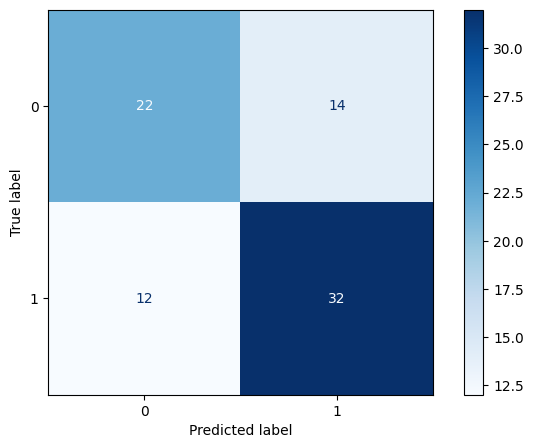

In [ ]:
# Confusion matrix for best model
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

best_name=comparison_df.iloc[0]['Model']
best_model=models[best_name]
ConfusionMatrixDisplay.from_estimator(best_model,X_test,y_test,cmap='Blues')
plt.show()


In [ ]:
# Save best model
import joblib
joblib.dump(best_model,'heart_disease_model.pkl')
print('Saved as heart_disease_model.pkl')


Saved as heart_disease_model.pkl


# Conclusion

- Compared Logistic Regression, Decision Tree, Random Forest, SVM (and any additional models).
- Selected the best model based on Accuracy, Precision, Recall, F1-score and ROC-AUC.
- The trained model can be deployed with FastAPI and Docker for real-world prediction services.
